Neural Networks
===============

Neural networks can be constructed using the `torch.nn` package.

Now that you had a glimpse of `autograd`, `nn` depends on `autograd` to
define models and differentiate them. An `nn.Module` contains layers,
and a method `forward(input)` that returns the `output`.

For example, look at this network that classifies digit images:

![convnet](https://pytorch.org/tutorials/_static/img/mnist.png)

It is a simple feed-forward network. It takes the input, feeds it
through several layers one after the other, and then finally gives the
output.

A typical training procedure for a neural network is as follows:

-   Define the neural network that has some learnable parameters (or
    weights)
-   Iterate over a dataset of inputs
-   Process input through the network
-   Compute the loss (how far is the output from being correct)
-   Propagate gradients back into the network's parameters
-   Update the weights of the network, typically using a simple update
    rule: `weight = weight - learning_rate * gradient`

Define the network
------------------

Let's define this network:


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super().__init__() #initializing the init func of the parent class
        # 1 input image channel, 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
          #fully connected layers
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # Convolution layer C1: 1 input image channel, 6 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a Tensor with size (N, 6, 28, 28), where N is the size of the batch
        c1 = F.relu(self.conv1(input))
        # Subsampling layer S2: 2x2 grid, purely functional,
        # this layer does not have any parameter, and outputs a (N, 6, 14, 14) Tensor
        s2 = F.max_pool2d(c1, (2, 2))
        # Convolution layer C3: 6 input channels, 16 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a (N, 16, 10, 10) Tensor
        c3 = F.relu(self.conv2(s2))
        # Subsampling layer S4: 2x2 grid, purely functional,
        # this layer does not have any parameter, and outputs a (N, 16, 5, 5) Tensor
        s4 = F.max_pool2d(c3, 2)
        # Flatten operation: purely functional, outputs a (N, 400) Tensor
        s4 = torch.flatten(s4, 1)
        # Fully connected layer F5: (N, 400) Tensor input,
        # and outputs a (N, 120) Tensor, it uses RELU activation function
        f5 = F.relu(self.fc1(s4))
        # Fully connected layer F6: (N, 120) Tensor input,
        # and outputs a (N, 84) Tensor, it uses RELU activation function
        f6 = F.relu(self.fc2(f5))
        # Fully connected layer OUTPUT: (N, 84) Tensor input, and
        # outputs a (N, 10) Tensor
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


### 1. `__init__(self)`: The Constructor

This is the *constructor* method for the `Net` class. It's called automatically when you create a new instance of `Net` (e.g., `net = Net()`). Its primary purpose is to define and initialize the layers of your neural network.

*   `super().__init__()`: This line calls the constructor of the parent class (`nn.Module`). It's essential for proper initialization of any PyTorch module.
*   **Convolutional Layers (`nn.Conv2d`):**
    *   `self.conv1 = nn.Conv2d(1, 6, 5)`: Defines the first convolutional layer. It takes 1 input channel (e.g., for a grayscale image), produces 6 output channels, and uses a 5x5 filter (kernel).
    *   `self.conv2 = nn.Conv2d(6, 16, 5)`: Defines the second convolutional layer. It takes the 6 channels from the previous layer as input, produces 16 output channels, and also uses a 5x5 filter.
*   **Fully Connected (Linear) Layers (`nn.Linear`):**
    *   `self.fc1 = nn.Linear(16 * 5 * 5, 120)`: This is the first fully connected layer. The input size `16 * 5 * 5` comes from flattening the output of the preceding max-pooling layer (16 channels, each 5x5 pixels). It outputs 120 features.
    *   `self.fc2 = nn.Linear(120, 84)`: The second fully connected layer, taking 120 features and outputting 84.
    *   `self.fc3 = nn.Linear(84, 10)`: The final fully connected layer, taking 84 features and outputting 10. In a classification task like digit recognition (0-9), this often corresponds to the 10 possible classes.

In essence, `__init__` sets up the blueprint for your network's architecture by declaring all the individual layers it will use.

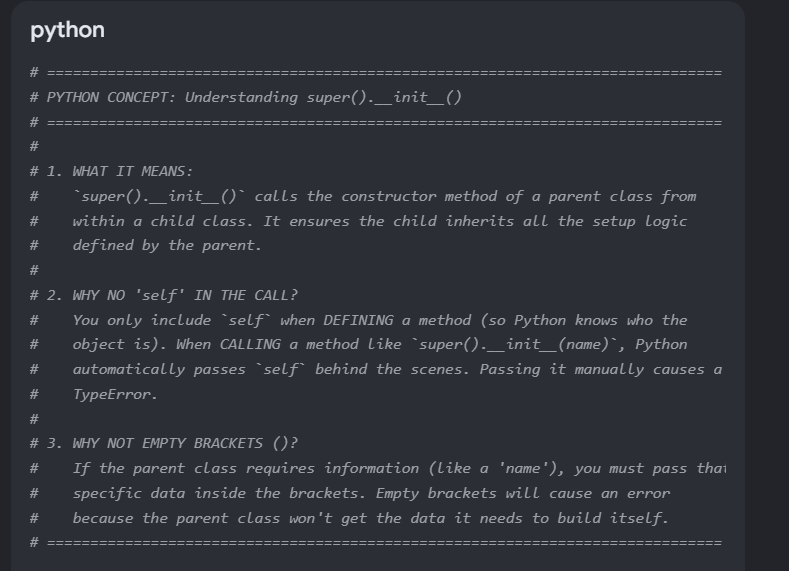

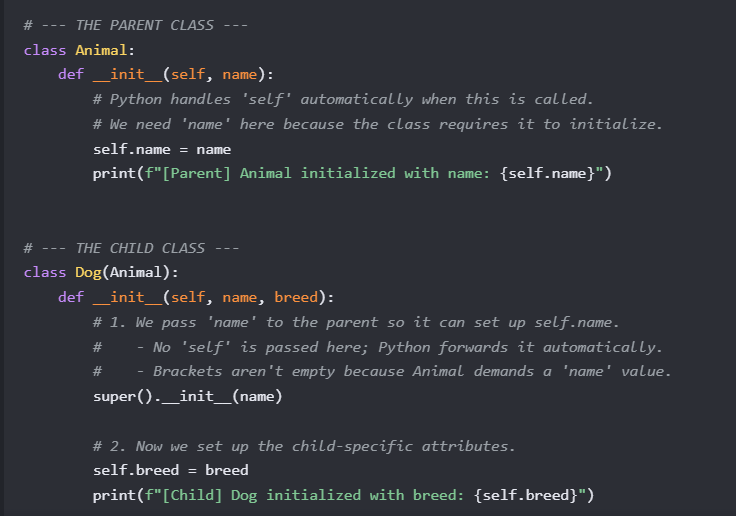

### 2. `forward(self, input)`: The Forward Pass

This method defines how data flows through the neural network from input to output. It describes the sequence of operations applied to the input tensor.

*   `c1 = F.relu(self.conv1(input))`: The input `input` first passes through `self.conv1` (the first convolutional layer), and then the result is passed through the Rectified Linear Unit (`F.relu`) activation function. `relu` introduces non-linearity, allowing the network to learn more complex patterns.
*   `s2 = F.max_pool2d(c1, (2, 2))`: The output of `c1` then goes through a max-pooling layer. `F.max_pool2d` with a `(2, 2)` kernel size reduces the spatial dimensions (height and width) of the feature maps by taking the maximum value in each 2x2 window. This helps in downsampling and making the network more robust to small shifts in input.
*   `c3 = F.relu(self.conv2(s2))`: Similar to `c1`, the output of `s2` passes through the second convolutional layer (`self.conv2`) and then `F.relu`.
*   `s4 = F.max_pool2d(c3, 2)`: Another max-pooling operation, reducing the feature map dimensions again.
*   `s4 = torch.flatten(s4, 1)`: Before passing the data to the fully connected layers, the multi-dimensional output of the convolutional layers (`s4`) is flattened into a 1D vector. The `1` argument means to flatten all dimensions starting from the second dimension (keeping the batch dimension intact).
*   `f5 = F.relu(self.fc1(s4))`: The flattened tensor `s4` is fed into the first fully connected layer (`self.fc1`), followed by `F.relu` activation.
*   `f6 = F.relu(self.fc2(f5))`: The output of `f5` goes through the second fully connected layer (`self.fc2`) and `F.relu`.
*   `output = self.fc3(f6)`: Finally, the output of `f6` passes through the last fully connected layer (`self.fc3`). This layer usually does not have an activation function applied immediately after it if the goal is to compute raw scores (logits) for classification, which are then typically fed into a loss function like cross-entropy that includes softmax.
*   `return output`: The method returns the final output of the network, which represents the model's prediction.

You just have to define the `forward` function, and the `backward`
function (where gradients are computed) is automatically defined for you
using `autograd`. You can use any of the Tensor operations in the
`forward` function.

The learnable parameters of a model are returned by `net.parameters()`


In [8]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


Let\'s try a random 32x32 input. Note: expected input size of this net
(LeNet) is 32x32. To use this net on the MNIST dataset, please resize
the images from the dataset to 32x32.


In [11]:
input = torch.randn(1, 1, 32, 32) #1image batch size, 1channel, 32h, 32w
out = net(input)
print(out)

tensor([[ 0.0909,  0.1709, -0.1178, -0.0496, -0.0652, -0.0073,  0.1338,  0.0675,
         -0.1130, -0.0331]], grad_fn=<AddmmBackward0>)


Zero the gradient buffers of all parameters and backprops with random
gradients:




</div>

Before proceeding further, let\'s recap all the classes you've seen so
far.

**Recap:**

:   -   `torch.Tensor` - A *multi-dimensional array* with support for
        autograd operations like `backward()`. Also *holds the gradient*
        w.r.t. the tensor.
    -   `nn.Module` - Neural network module. *Convenient way of
        encapsulating parameters*, with helpers for moving them to GPU,
        exporting, loading, etc.
    -   `nn.Parameter` - A kind of Tensor, that is *automatically
        registered as a parameter when assigned as an attribute to a*
        `Module`.
    -   `autograd.Function` - Implements *forward and backward
        definitions of an autograd operation*. Every `Tensor` operation
        creates at least a single `Function` node that connects to
        functions that created a `Tensor` and *encodes its history*.

**At this point, we covered:**

:   -   Defining a neural network
    -   Forward Pass

**Still Left:**

:   -   Computing the loss
    -   Backprop and Updating the weights of the network

Loss Function
=============

A loss function takes the (output, target) pair of inputs, and computes
a value that estimates how far away the output is from the target.

There are several different [loss
functions](https://pytorch.org/docs/nn.html#loss-functions) under the nn
package . A simple loss is: `nn.MSELoss` which computes the mean-squared
error between the output and the target.

For example:


In [14]:
output = net(input)
target = torch.randn(1,10) # a dummy target, for example
target = target.view(1,-1)  # make it the same shape as output
criterion = nn.MSELoss()
loss = criterion(output, target)
print(loss)

tensor(0.6395, grad_fn=<MseLossBackward0>)


Now, if you follow `loss` in the backward direction, using its
`.grad_fn` attribute, you will see a graph of computations that looks
like this:

``` {.sh}
input -> conv2d -> relu -> maxpool2d -> conv2d -> relu -> maxpool2d
      -> flatten -> linear -> relu -> linear -> relu -> linear
      -> MSELoss
      -> loss
```

So, when we call `loss.backward()`, the whole graph is differentiated
w.r.t. the neural net parameters, and all Tensors in the graph that have
`requires_grad=True` will have their `.grad` Tensor accumulated with the
gradient.

For illustration, let us follow a few steps backward:


Backprop
========

To backpropagate the error all we have to do is to `loss.backward()`.
You need to clear the existing gradients though, else gradients will be
accumulated to existing gradients.

Now we shall call `loss.backward()`, and have a look at conv1\'s bias
gradients before and after the backward. Since we have not introduced an
optimizer yet, we clear the gradients directly on the model. Once using
an optimizer, prefer `optimizer.zero_grad()` as shown below.


### 1. `net.zero_grad()`

*   **What it does:** This line zeroes out the gradients of all parameters (weights and biases) in your neural network (`net`).
*   **Why it's needed:** In PyTorch, by default, gradients are *accumulated* rather than overwritten. This means that if you perform multiple `backward()` calls without clearing the gradients, the new gradients will be added to the existing ones. While this can be useful in some advanced scenarios (like accumulating gradients over multiple mini-batches before a single update step), it's usually not what you want during a standard training loop. You typically want a fresh set of gradients for each optimization step.
*   **Context:** Before performing a new backpropagation step, it's crucial to call `net.zero_grad()` (or `optimizer.zero_grad()` if using an optimizer) to ensure that the gradients calculated for the current batch are not mixed with gradients from previous batches.

### 2. `out.backward(torch.randn(1, 10))`

*   **What it does:** This line initiates the backpropagation process through the neural network, starting from the `out` tensor.
*   **Why it's needed:** The `backward()` method is how PyTorch's `autograd` engine computes gradients. When you call `tensor.backward()`, it computes the gradients of `tensor` with respect to all parameters that `tensor` depends on (i.e., all learnable parameters in `net`).
*   **The `torch.randn(1, 10)` argument:** Normally, `backward()` is called on a *scalar* (single-value) output, typically the `loss` of the network. When `backward()` is called on a non-scalar output (like `out`, which is a `(1, 10)` tensor here), you need to provide a `gradient` argument of the same shape as `out`. This argument represents the gradient of some scalar loss function with respect to `out`.
    *   In this specific example, `torch.randn(1, 10)` is used to provide a *dummy* gradient. This is often done for illustration purposes or when debugging, simulating a situation where the network's output is fed into some hypothetical loss function that produces a gradient of that shape. In a real training scenario, you would typically calculate a loss (e.g., `loss = criterion(output, target)`) and then call `loss.backward()` without any arguments, as `loss` would be a scalar.

In [16]:
net.zero_grad()     # zeroes the gradient buffers of all parameters

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([-0.0129,  0.0012,  0.0038,  0.0045,  0.0057, -0.0027])


Now, we have seen how to use loss functions.

**Read Later:**

> The neural network package contains various modules and loss functions
> that form the building blocks of deep neural networks. A full list
> with documentation is [here](https://pytorch.org/docs/nn).

**The only thing left to learn is:**

> -   Updating the weights of the network

Update the weights
==================

The simplest update rule used in practice is the Stochastic Gradient
Descent (SGD):

``` {.python}
weight = weight - learning_rate * gradient
```

We can implement this using simple Python code:

``` {.python}
learning_rate = 0.01
for f in net.parameters():
    with torch.no_grad():
        f -= f.grad * learning_rate
```
weight = weight - learning_rate * gradient we implement like
learning_rate = 0.01
for f in net.parameters():
    with torch.no_grad():
        f -= f.grad * learning_rate


However, as you use neural networks, you want to use various different
update rules such as SGD, Nesterov-SGD, Adam, RMSProp, etc. To enable
this, we built a small package: `torch.optim` that implements all these
methods. Using it is very simple:

``` {.python}
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update
```


In [20]:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update